# Nonlinear Models: Learning What Physics Doesn't Capture Easily

**Companion notebook to Chapter 53 — Nonlinear Models: Learning What Physics Doesn't Capture Easily.**

*When a straight line meets a yield knee, the line loses — and the interesting question becomes which nonlinear model wins, and by how much.*

Linear models fail when the relationship between input and output is genuinely nonlinear. The stress–strain curve of a metal above its yield point is one such case: below yield, stress and strain are proportional (a relationship linear regression handles exactly), but above yield the material work-hardens in a way that no linear combination of the raw inputs can represent. The error is not noise — it is *structural*, baked into the model class itself.

**Random forests** and **neural networks** — two of the most widely used nonlinear model classes in structural measurement — approach this problem differently. A random forest builds many decision trees, each trained on a random subset of data and features, and averages their predictions; it is robust, yields feature-importance estimates, and needs little tuning. A neural network learns a hierarchy of nonlinear transformations through stacked layers and activation functions; it can represent more complex functions but needs more data and more careful training to avoid overfitting.

Both vastly outperform linear regression on this nonlinear problem. The comparison below is trained on the full elastic–plastic response of aluminum 6061-T6 from 0 to 5% strain — a range spanning more than twelve times the yield strain. The linear model cannot bend at the yield knee, so it splits the difference and explains only a small fraction of the variance; the random forest tracks the curve closely, with visible staircase steps from its piecewise-constant trees; the neural network fits an equally close but smoother curve through the yield transition. On these data the two nonlinear models are effectively tied — the random forest edges ahead by a hair. The 2nd-order polynomial baseline improves on the straight line but stays far behind either nonlinear model.

**This notebook demonstrates:**
1. A five-model comparison — linear, polynomial, a three-parameter Ramberg–Osgood physics fit, random forest, neural network — on the aluminum 6061-T6 stress–strain response, spanning the elastic region and the plastic work-hardening regime.

In [1]:
# Colab setup — install dependencies (uncomment on first run):
# !pip install numpy matplotlib scikit-learn

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq, curve_fit

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Output directory for the figure this notebook saves (do not rename the file).
OUT_DIR = Path("../src/media/ch53")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Aluminum 6061-T6 Stress–Strain Response: Four-Model Comparison

The simulation generates 800 samples from the elastic–plastic response of aluminum 6061-T6 using a Ramberg–Osgood-inspired model with a smooth yield transition at 276 MPa (yield strain ≈ 4,006 µε). The axial strain ranges from 0 to 50,000 µε (5% — well into the plastic regime), with transverse strain coupled through Poisson's ratio plus measurement noise. Both axial and transverse strain are used as model inputs.

The five models span the complexity hierarchy: first-order linear, second-order polynomial, a three-parameter Ramberg–Osgood fit (ε = σ/E + 0.002(σ/σ₀.₂)ⁿ, the classical closed form for a metal's elastic–plastic curve, and deliberately *not* the function that generated the data), random forest (200 trees), and a three-layer neural network (128–64–32 units). Results are printed first as an R² and RMSE table, then visualized as five response-curve panels (measured solid, predicted dashed) and a summary panel of held-out RMSE.

The response curves make the failure mode of the linear model visible: a single straight line cannot follow the sharp yield knee, so it over-predicts stress through the elastic region and cannot represent the plateau, ending with an R² of only about 0.12. The polynomial model improves only marginally (R² ≈ 0.21) — a quadratic still cannot bend sharply enough at the knee. The random forest and neural network both track the curve well throughout: the random forest with a slight staircase from its piecewise-constant trees, the neural network with the smoothest fit near the yield knee.

The quantitative advantage of the nonlinear models is dramatic — RMSE near 2.7–2.9 MPa versus about 31 MPa for the linear fit, and R² near 0.993 versus 0.12. On these metrics the random forest edges the neural network (R² 0.993 vs 0.992; RMSE 2.73 vs 2.92 MPa), a gap small enough to treat the two as effectively tied here. That advantage is large enough to matter in fatigue-life calculations, where small errors in peak stress translate into large errors in predicted cycle count.

The Ramberg–Osgood fit is the lesson of the comparison. With three parameters that each mean something (E ≈ 69.3 GPa, σ₀.₂ ≈ 287 MPa, n ≈ 36) it scores R² ≈ 0.992 and RMSE ≈ 3.0 MPa, tied with the random forest and the neural network, and unlike them it extrapolates along a physically sensible curve. When a closed form exists, fit it first; reach for the random forest or the network when no closed form does. Note also that only 7 of the 160 test points lie on the elastic branch below yield, so every R² here mostly measures the plateau.

Model                         R²    RMSE (MPa)
------------------------------------------------
Linear (1st order)        0.1241         30.96
Linear (2nd order)        0.2061         29.48
Ramberg-Osgood (physics)    0.9916          3.03
Random Forest             0.9932          2.73
Neural Network            0.9922          2.92
  (NN stopped at iteration 1045)
Ramberg-Osgood fit: E = 69.3 GPa, sigma_0.2 = 287 MPa, n = 36
Test points on the elastic branch (< 4006 ue): 7 of 160


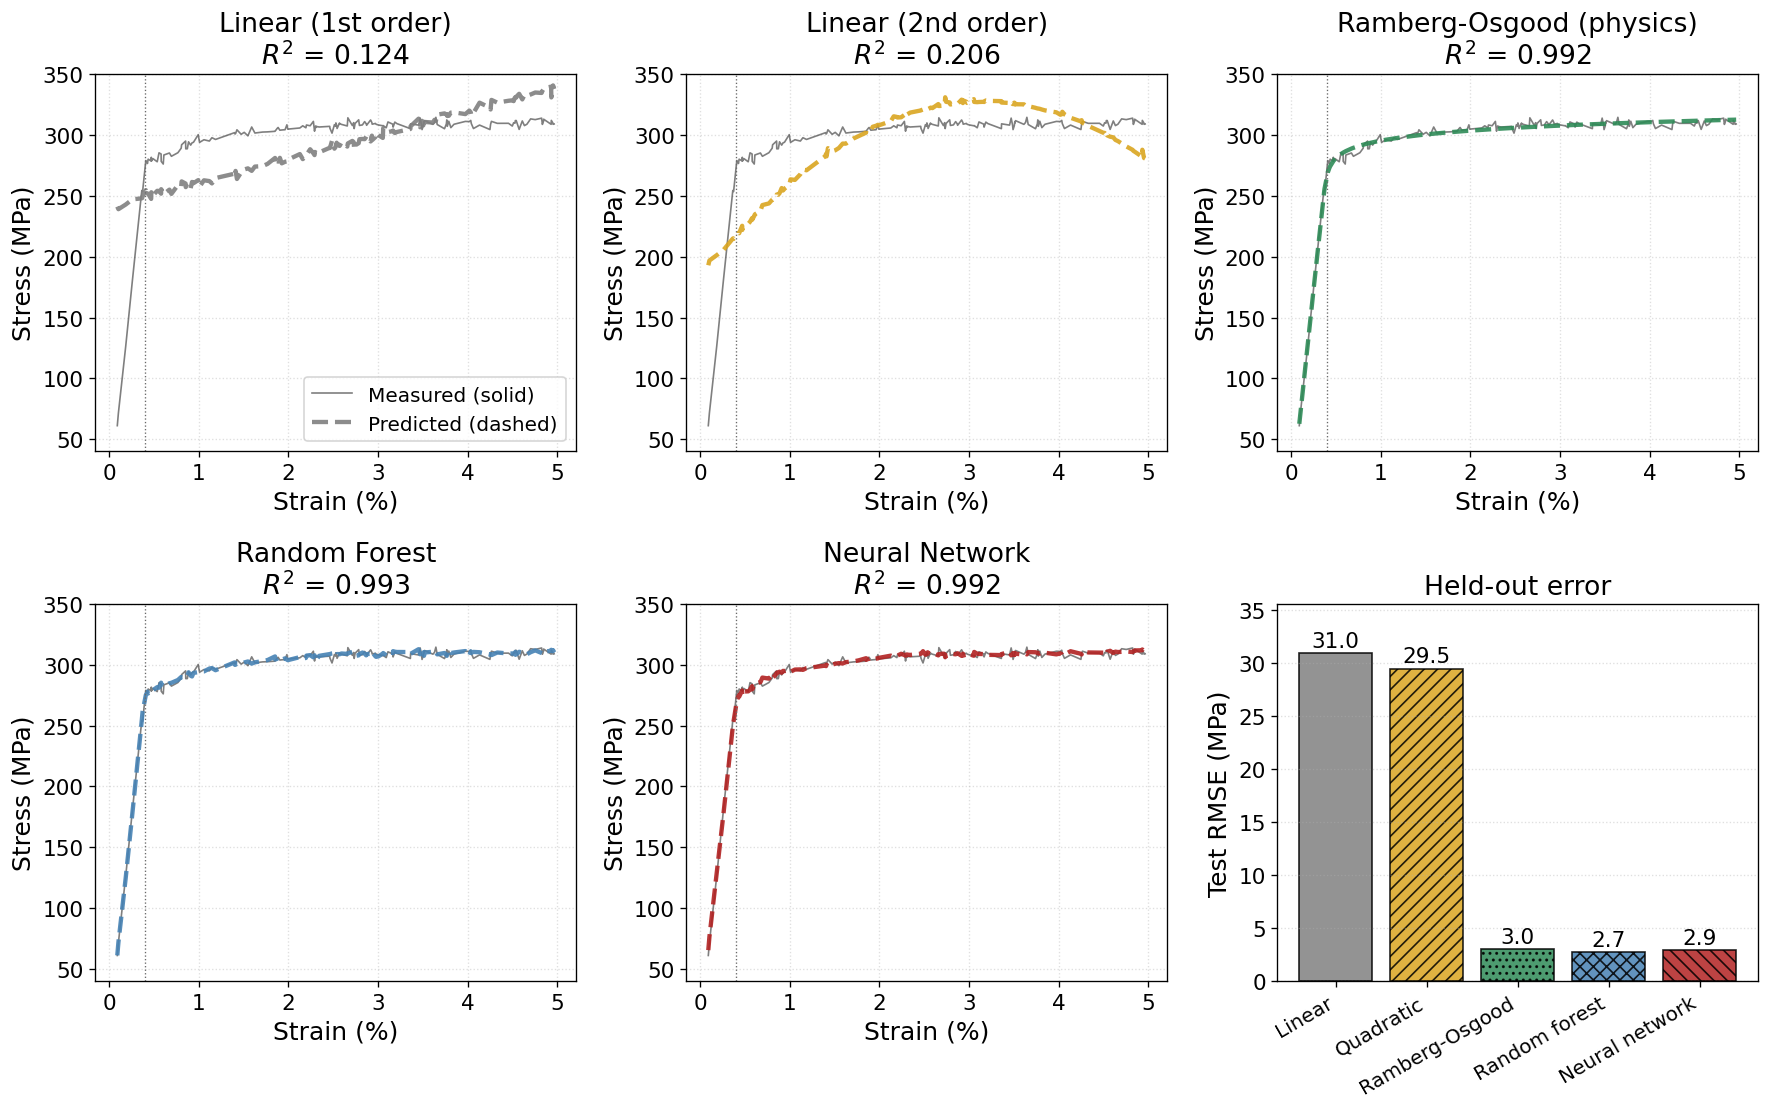

In [2]:
# =====================================================================
# Aluminum 6061-T6 stress-strain response: four-model ML comparison
# =====================================================================
# Reproducibility: the synthetic dataset and every estimator are seeded,
# so this notebook produces identical numbers and figures on each run.

RANDOM_SEED = 42     # global NumPy RNG seed for the synthetic dataset
SPLIT_STATE = 0      # train/test split seed
MODEL_STATE = 0      # estimator random_state (random forest, MLP)

# --- Aluminum 6061-T6 material properties ---
E_MPA     = 68900    # Young's modulus (MPa)
SIGMA_Y   = 276      # 0.2%-offset yield strength (MPa)
SIGMA_UTS = 310      # ultimate tensile strength (MPa)
NU        = 0.33     # Poisson's ratio

# --- Synthetic-dataset parameters ---
N_SAMPLES           = 800    # number of synthetic gage readings
STRAIN_MAX_UE       = 50000  # maximum axial strain (µε) = 5%, well into plastic regime
HARDENING_UE        = 8000   # work-hardening decay constant (µε)
YIELD_KNEE_UE       = 150    # width of the smooth yield transition (µε)
TRANSVERSE_NOISE_UE = 600    # scatter on the Poisson-coupled transverse strain (µε)
GAGE_NOISE_MPA      = 2.5    # stress measurement noise (MPa)

# --- Model hyperparameters ---
RF_N_ESTIMATORS = 200            # trees in the random forest
NN_LAYERS       = (128, 64, 32)  # hidden-layer sizes of the MLP
TEST_FRACTION   = 0.2            # held-out test split

# Yield strain in µε (~4006): where the elastic branch gives way to hardening.
eps_y_ue = SIGMA_Y / (E_MPA * 1e-6)


def al_stress(eps_ue):
    """Ramberg-Osgood-inspired 6061-T6 axial stress response.

    Maps axial strain (µε) to axial stress (MPa): a linear elastic branch
    below yield, blended through a smooth tanh knee into a work-hardening
    branch that saturates toward the ultimate tensile strength.
    """
    sigma_elastic = E_MPA * 1e-6 * eps_ue
    excess = np.maximum(0.0, eps_ue - eps_y_ue)
    sigma_harden = SIGMA_Y + (SIGMA_UTS - SIGMA_Y) * (1 - np.exp(-excess / HARDENING_UE))
    knee = 0.5 * (1 + np.tanh((eps_ue - eps_y_ue) / YIELD_KNEE_UE))   # 0 below yield, 1 above
    return sigma_elastic * (1 - knee) + sigma_harden * knee


# --- Synthetic strain gage dataset (deterministic) ---
np.random.seed(RANDOM_SEED)
eps1 = np.random.uniform(0, STRAIN_MAX_UE, N_SAMPLES)                     # axial strain (µε), 0-5%
eps2 = -NU * eps1 + np.random.normal(0, TRANSVERSE_NOISE_UE, N_SAMPLES)   # transverse (Poisson + noise)
sigma = al_stress(eps1) + np.random.normal(0, GAGE_NOISE_MPA, N_SAMPLES)  # stress + gage noise

X = np.column_stack([eps1, eps2])
y = sigma
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_FRACTION, random_state=SPLIT_STATE)

# Scale inputs for the neural network only; fit on TRAIN, apply to TEST (no leakage).
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_tr)
Xte_s = scaler.transform(X_te)

# --- Physics form: a three-parameter Ramberg-Osgood fit ---
# eps = sigma/E + 0.002 (sigma/sigma_02)^n, the classical closed form for a
# metal's elastic-plastic curve. It is not the function that generated the
# data (that is the tanh-blended elastic/saturating-hardening curve above),
# so the fit is a fair test of a physics form against the learned models.
def ro_stress(eps, E, sigma_02, n):
    """Invert Ramberg-Osgood numerically: strain (dimensionless) -> stress (MPa)."""
    eps = np.atleast_1d(eps)
    return np.array([brentq(lambda s: s / E + 0.002 * (s / sigma_02) ** n - e, 0.0, 2000.0)
                     for e in eps])


class RambergOsgoodModel:
    """Least-squares Ramberg-Osgood fit on axial strain, with a scikit-learn-style predict()."""

    def fit(self, X, y):
        self.params_, _ = curve_fit(ro_stress, X[:, 0] * 1e-6, y, p0=[69000, 276, 20],
                                    bounds=([30000, 150, 2], [120000, 400, 200]))
        return self

    def predict(self, X):
        return ro_stress(X[:, 0] * 1e-6, *self.params_)


# --- Fit the five models ---
lr1 = LinearRegression().fit(X_tr, y_tr)
lr2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                    LinearRegression()).fit(X_tr, y_tr)
ro = RambergOsgoodModel().fit(X_tr, y_tr)
rf = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=MODEL_STATE).fit(X_tr, y_tr)
nn = MLPRegressor(
    hidden_layer_sizes=NN_LAYERS,
    max_iter=5000,
    early_stopping=True,
    n_iter_no_change=30,
    validation_fraction=0.1,
    random_state=MODEL_STATE,
).fit(Xtr_s, y_tr)

# Each entry: (label, fitted model, its test inputs, plot color).
# The neural network sees scaled inputs; the others see raw strain.
models = [
    ('Linear (1st order)', lr1, X_te,  'gray'),
    ('Linear (2nd order)', lr2, X_te,  'goldenrod'),
    ('Ramberg-Osgood (physics)', ro, X_te, 'seagreen'),
    ('Random Forest',      rf,  X_te,  'steelblue'),
    ('Neural Network',     nn,  Xte_s, 'firebrick'),
]

print(f"{'Model':22s}  {'R²':>8}  {'RMSE (MPa)':>12}")
print('-' * 48)
for name, model, Xte, _ in models:
    yp = model.predict(Xte)
    print(f"{name:22s}  {r2_score(y_te, yp):8.4f}  {np.sqrt(mean_squared_error(y_te, yp)):12.2f}")
print(f"  (NN stopped at iteration {nn.n_iter_})")
E_fit, s02_fit, n_fit = ro.params_
print(f"Ramberg-Osgood fit: E = {E_fit/1000:.1f} GPa, sigma_0.2 = {s02_fit:.0f} MPa, n = {n_fit:.0f}")
print(f"Test points on the elastic branch (< {eps_y_ue:.0f} ue): {(X_te[:, 0] < eps_y_ue).sum()} of {len(X_te)}")

# --- Sort the test set by axial strain so the response curve reads left to right ---
order  = np.argsort(X_te[:, 0])
x_axis = X_te[order, 0]   # axial strain (µε)
y_true = y_te[order]

# Five response panels plus a summary panel, on a 2 x 3 grid sized for a
# 5.8-inch print column (large fonts so labels survive the reduction).
with plt.rc_context({'font.size': 15, 'axes.titlesize': 16, 'axes.labelsize': 15,
                     'xtick.labelsize': 13, 'ytick.labelsize': 13}):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
    panels = axes.ravel()
    r2s, rmses = [], []

    for col, (name, model, Xte, color) in enumerate(models):
        yp_all  = model.predict(Xte)
        yp_sort = yp_all[order]
        r2s.append(r2_score(y_te, yp_all))
        rmses.append(np.sqrt(mean_squared_error(y_te, yp_all)))

        # True and predicted differ by line style as well as color, so the panels
        # read in the black-and-white softcover (and panel 1, where both are gray).
        ax = panels[col]
        ax.plot(x_axis / 1e4, y_true,  color='black', lw=1.0, alpha=0.5, ls='-',  label='Measured (solid)')
        ax.plot(x_axis / 1e4, yp_sort, color=color,   lw=2.6, alpha=0.9,  ls='--', label='Predicted (dashed)')
        ax.axvline(eps_y_ue / 1e4, color='dimgray', lw=0.8, ls=':')
        ax.set_title(f'{name}\n$R^2$ = {r2s[-1]:.3f}')
        ax.set_xlabel('Strain (%)')
        ax.set_ylabel('Stress (MPa)')
        ax.set_ylim(40, 350)
        ax.grid(True, linestyle=':', alpha=0.4)
        if col == 0:
            ax.legend(loc='lower right', fontsize=12)

    # Summary panel: test RMSE per model. Hatching distinguishes the bars in B&W.
    ax = panels[5]
    short = ['Linear', 'Quadratic', 'Ramberg-Osgood', 'Random forest', 'Neural network']
    hatches = ['', '///', '...', 'xxx', '\\\\\\']
    bars = ax.bar(range(len(models)), rmses, color=[m[3] for m in models],
                  edgecolor='black', alpha=0.85)
    for bar, h, v in zip(bars, hatches, rmses):
        bar.set_hatch(h)
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, f'{v:.1f}', ha='center', fontsize=13)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(short, fontsize=12, rotation=30, ha='right')
    ax.set_ylabel('Test RMSE (MPa)')
    ax.set_title('Held-out error')
    ax.set_ylim(0, max(rmses) * 1.15)
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig53_nb1_ml_stress_strain_comparison.png', bbox_inches='tight', dpi=300)
    plt.show()

---
## Where to take this next

The comparison above is a starting point, not a finished study. Three concrete extensions:

1. **Turn the random split into an extrapolation test.** Replace the random 80/20 split with a *domain* split — train only on the elastic branch (strain below first yield, roughly ≤ 4,000 µε) and test on the plastic branch above it. Watch the random forest flat-line at the largest response value it ever saw, while the neural network drifts off with no guarantee of obeying the material curve. This makes the chapter's "interpolation is not extrapolation" warning visible in a single figure.

2. **Try residual modeling against the physics.** Fit the elastic law σ = Eε as a physics baseline, subtract it, and train the random forest and neural network on the *residual* only — the post-yield hardening the elastic law omits. Compare validation error against the direct fit. This is the chapter's "extend, don't replace, physics" idea made concrete, and it usually shrinks the part the model has to learn.

3. **Swap in real data and add history.** Replace the synthetic Ramberg–Osgood curve with a real tensile-test record, or add a load/unload hysteresis loop, and re-fit. A feedforward model given only the current strain cannot represent path dependence; use this to motivate the lagged features and sequence models developed in Chapter 57.